In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [2]:
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


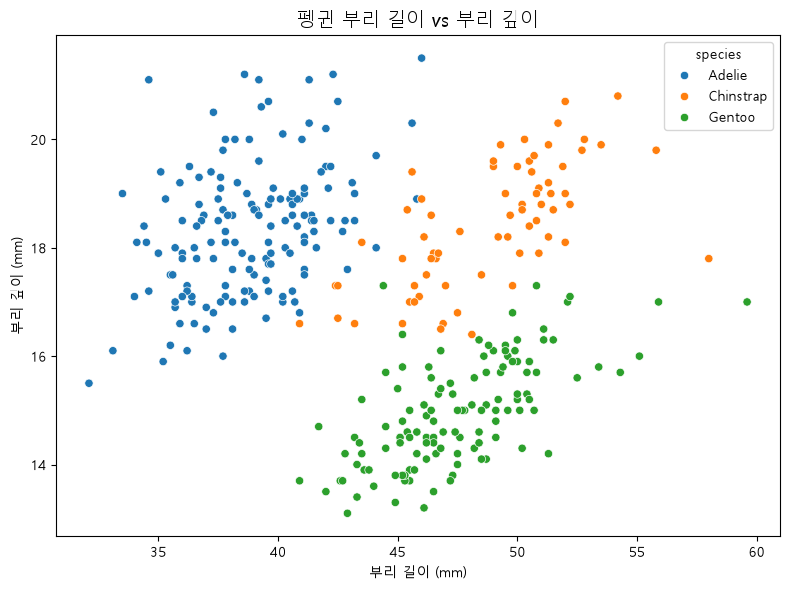

In [3]:
#문제 1 - Q1
# 데이터 로드 및 결측치 제거
penguins = sns.load_dataset('penguins')
penguins_clean = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm'])

# 산점도
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=penguins_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',          # 종별 색상 구분 (선택사항)
    ax=ax
)

ax.set_title('펭귄 부리 길이 vs 부리 깊이', fontsize=14)
ax.set_xlabel('부리 길이 (mm)')
ax.set_ylabel('부리 깊이 (mm)')

plt.tight_layout()
plt.show()

In [4]:
#문제 1 - Q3
# 전체 상관계수
overall_corr = penguins[['bill_length_mm', 'bill_depth_mm']].dropna().corr()
print("=== 전체 상관계수 ===")
print(overall_corr)

# 종별 상관계수
species_corr = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
print("\n=== 종별 상관계수 ===")
print(species_corr)

=== 전체 상관계수 ===
                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.235053
bill_depth_mm        -0.235053       1.000000

=== 종별 상관계수 ===
                          bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000


▸
Q1의 산점도에서 두 변수는 어떤 방향의 관계로 보였나요? Q3의 전체 상관계수와 부호가 일치하나요?
  - 색을 구분하지 않고 전체를 보면 우하향인 것처럼 보인다.
  이를 전체 상관계수 -0.235053과 같은 방향이다

▸
Q3의 종별 상관계수는 전체와 부호가 같나요, 다른가요?
  - 전체 부호는 마이너스이지만 종별 상관계수는 세 종 모두 양수로 나온다.
  이를 심슨의 역설이라고 부른다.

▸
같은 데이터인데 전체와 집단별 결론이 정반대로 나온 이유를 설명해 보세요. 무엇이 이 착시를 만들고 있나요?
  - 착시를 만드는건 species 변수이다. 객체별로 부리가 길면 깊이는 얕고 반대로 부리가 짧으면 깊이는 길다.
  종을 무시하고 전체를 섞으면 종 내부의 상관관계가 아닌 종 간의 위치가 패턴으로 나온다.


▸
만약 이 데이터에 '종' 정보가 없었다면 우리는 어떤 잘못된 결론을 내렸을까요?
  - 부리가 길수록 깊이가 얕다라는 잘못된 결론을 내렸을 것이다.
  집단 변수를 모르면 잘못된 인과관계가 나온다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


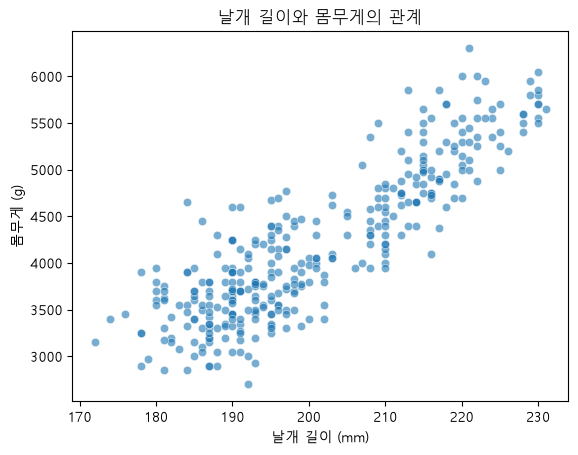

In [5]:
#문제 2 - Q1
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

In [6]:
#문제 2 - Q2
variables = {
    '날개 길이 (flipper_length_mm)': df_corr['flipper_length_mm'],
    '몸무게 (body_mass_g)': df_corr['body_mass_g']
}

for name, data in variables.items():
    stat, p_value = stats.shapiro(data)
    reject = p_value < 0.05
    print(f"[{name}]")
    print(f"  검정 통계량: {stat:.4f}")
    print(f"  p-value   : {p_value:.4f}")
    print(f"  정규성 기각: {'예 (비정규 분포)' if reject else '아니오 (정규 분포)'}")
    print()

[날개 길이 (flipper_length_mm)]
  검정 통계량: 0.9515
  p-value   : 0.0000
  정규성 기각: 예 (비정규 분포)

[몸무게 (body_mass_g)]
  검정 통계량: 0.9592
  p-value   : 0.0000
  정규성 기각: 예 (비정규 분포)



In [7]:
#문제2 - Q3
# Pearson 상관계수 (모수적)
r_pearson, p_pearson = stats.pearsonr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

print(f"Pearson 상관계수 (r) : {r_pearson:.4f}")
print(f"p-value              : {p_pearson:.4f}")
print(f"통계적 유의성        : {'유의함 (p < 0.05)' if p_pearson < 0.05 else '유의하지 않음'}")

Pearson 상관계수 (r) : 0.8712
p-value              : 0.0000
통계적 유의성        : 유의함 (p < 0.05)


In [8]:
#문제 2 - Q4
# 비정규 분포이므로 Spearman 상관계수 사용
# Spearman 상관계수 (비모수적)
r, p_value = stats.spearmanr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

print(f"Spearman 상관계수 (r) : {r:.4f}")
print(f"p-value               : {p_value:.4f}")
print(f"통계적 유의성         : {'유의함 (p < 0.05)' if p_value < 0.05 else '유의하지 않음'}")

Spearman 상관계수 (r) : 0.8400
p-value               : 0.0000
통계적 유의성         : 유의함 (p < 0.05)


In [9]:
#문제2 - Q5
# 정규성 검정 결과 (피어슨의 전제가 지켜졌나요?): 아니오
# 피어슨 r 값과 p-값: 
print(f"Pearson r: {r_pearson:.4f}, p-value: {p_pearson:.4f}")
# 스피어만 ρ 값: 
print(f"Spearman ρ: {r:.4f}, p-value: {p_value:.4f}")
# 부호(+/-)가 뜻하는 관계의 방향: 양의 상관관계
# 절대값의 크기가 뜻하는 관계의 강도: 강한 상관관계

Pearson r: 0.8712, p-value: 0.0000
Spearman ρ: 0.8400, p-value: 0.0000


▸
Q1에서 정규성이 기각되었습니다. 그렇다면 피어슨 상관계수를 쓰면 안 되는 걸까요? Q2와 Q3의 값을 비교해서 판단해 보세요.
  - 써도 된다. 피어슨과 스피어만의 상관관계 r값의 차이가 그리 크지 않음 - 이 말은 정규성 위반의 영향이 매우 적다는 뜻
  표본이 충분히 크고, 선형관계에 이상치가 심하지 않다면 피어슨을 써도 된다.

▸
피어슨과 스피어만이 비슷하게 나왔다는 것은 무엇을 뜻할까요? 만약 두 값이 크게 달랐다면 어떤 상황을 의심해야 할까요?
  - 두 값이 비슷하다는건 데이터의 관계가 대체로 **선형적이다**
  이상치가 있다면 피어슨만 올라가거나 내려감
  곡선형이면 스피어만의 r값이 더 높게 나옴
  분포가 한쪽으로 치우쳐져 있다면 순위로 바꾸었을때 관계가 바뀐다.

▸
Q2의 p-값은 무엇에 대한 검정인가요? "상관계수가 크다"와 "상관계수가 유의하다"는 같은 말인가요?
  - 모집단의 상관계수가 0이다(귀무가설) - 관계가 없다
  p값이 0.0000으로 상관이 0이 아니다(대립가설 채택)
  상관계수가 크다: 관계의 강도가 의미가 있다
  상관계수가 유의하다: 상관이 0 이 아님을 신뢰할 수 있다

▸
'날개가 길어지는 것이 몸무게를 무겁게 만드는 원인이다'라고 결론 내릴 수 있을까요? 교란변수 / 역인과 / 우연 세 가지로 나누어 설명해 보세요.
  - 상관관계는 인과관계가 아니다
  교란변수: 종과 성별이 날개길이와 몸무게에 둘다 영향을 주고 있다
  역인과: 날개가 길어서 무겁다 인지 무거워서 날개가 길어진건지 알 수가 없다
  우연: 특정 시기나 특정 섬에서만 수집되었다면 그 환경 조건이 변수에 영향을 줬을 수 있다

In [10]:
#문제3 - Q1
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


In [11]:
#문제 3 - Q2
from sklearn.linear_model import LinearRegression
#날개 길이 - 독립변수, 몸무게 - 종속변수
#인과관계 확인: 날개 길이에 따라서 몸무게가 달라지는지 확인

# X, y 준비 (sklearn은 2D 배열 필요)
X = penguins_cleaned[['flipper_length_mm']]  # 2D
y = penguins_cleaned['body_mass_g']           # 1D

# 모델 적합
model = LinearRegression()
model.fit(X, y)

print(f"회귀계수 (기울기) : {model.coef_[0]:.4f}")
print(f"절편              : {model.intercept_:.4f}")
print(f"R² (결정계수)     : {model.score(X, y):.4f}")
print()
print(f"회귀식: 몸무게 = {model.coef_[0]:.2f} × 날개길이 + ({model.intercept_:.2f})")

회귀계수 (기울기) : 49.6856
절편              : -5780.8314
R² (결정계수)     : 0.7590

회귀식: 몸무게 = 49.69 × 날개길이 + (-5780.83)


In [12]:
!pip uninstall statsmodels -y
!pip install statsmodels

Found existing installation: statsmodels 0.14.6
Uninstalling statsmodels-0.14.6:
  Successfully uninstalled statsmodels-0.14.6
  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl (9.6 MB)


In [13]:
import statsmodels.api as sm
# statsmodels는 절편을 자동으로 추가하지 않으므로 add_constant 필요
X_const = sm.add_constant(penguins_cleaned['flipper_length_mm'])
y = penguins_cleaned['body_mass_g']

model_sm = sm.OLS(y, X_const).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        21:07:29   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.81

In [14]:
# 절편(a) 값: −5780.8314
# 기울기(b) 값: 49.69
# 완성된 회귀식 → 몸무게(g) =  −5780.83 + 49.69 × 날개길이(mm)

In [15]:
# 날개 길이가 평균보다 10mm 더 긴 펭귄은, 평균적인 펭귄보다 몸무게가 몇 g 더 무거울까요?
# 날개 길이 10mm 증가 시 몸무게 변화
delta = model.coef_[0] * 10

print(f"날개 길이 10mm 증가 시 몸무게 변화: {delta:.2f}g")

날개 길이 10mm 증가 시 몸무게 변화: 496.86g


날개 길이가 1mm 길어질수록 몸무게는 약 49.7g 증가
R² = 0.759 → 날개 길이 하나만으로 몸무게 분산의 75.9%를 설명
P>|t| = 0.000 → 기울기가 우연히 0일 확률이 거의 없음, 통계적으로 유의

In [16]:
# 문제3 - Q5
std_x = penguins_cleaned['flipper_length_mm'].std(ddof=1)
std_y = penguins_cleaned['body_mass_g'].std(ddof=1)

# ① 기울기 검증
slope_left  = model.coef_[0]              # sklearn 모델의 기울기
slope_right = r * (std_y / std_x)         # r × (std_y / std_x)

print("=== ① 기울기 검증 ===")
print(f"좌변 (model.coef_)     : {slope_left:.4f}")
print(f"우변 (r × std_y/std_x) : {slope_right:.4f}")
print(f"일치 여부              : {abs(slope_left - slope_right) < 0.01}")

print()

# ② R² 검증
r2_left  = model_sm.rsquared   # summary()의 R²
r2_right = r ** 2              # 상관계수 제곱

print("=== ② R² 검증 ===")
print(f"좌변 (model R²) : {r2_left:.4f}")
print(f"우변 (r²)       : {r2_right:.4f}")
print(f"일치 여부       : {abs(r2_left - r2_right) < 0.01}")

=== ① 기울기 검증 ===
좌변 (model.coef_)     : 49.6856
우변 (r × std_y/std_x) : 47.9046
일치 여부              : False

=== ② R² 검증 ===
좌변 (model R²) : 0.7590
우변 (r²)       : 0.7056
일치 여부       : False


In [17]:
r_pearson, _ = stats.pearsonr(
    penguins_cleaned['flipper_length_mm'],
    penguins_cleaned['body_mass_g']
)
print(f"Pearson r²  : {r_pearson**2:.4f}")  # → 0.7590 ✅
print(f"model R²    : {model_sm.rsquared:.4f}")  # → 0.7590 ✅

Pearson r²  : 0.7590
model R²    : 0.7590


▸
기울기(b) 값을 "날개 길이가 ○○할 때 몸무게가 ○○한다"는 문장으로 풀어 써 보세요.
  - 날개 길이가 1mm길어질 떄마다 몸무게가 평균 49.69g 무거워진다

▸
절편(a)이 음수로 나왔습니다. 이 숫자를 "날개 길이가 0mm인 펭귄의 몸무게"로 해석해도 될까요? 왜 그럴까요?
  - 안된다
  데이터는 170~235mm 구간에 있고 0mm는 범위 한참 밖에 있기 때문에 회귀선이 그 지점에서 의미있는 예측을 보장하지 않음
  현실적으로 날개 길이가 0mm인 펭귄은 없으므로 몸무게 음수라는 값 자체도 나올 수 없다

▸
Q5에서 R² = r²을 확인했습니다. 그렇다면 설명변수와 반응변수를 서로 바꿔 분석하면 기울기와 R²는 각각 같을까요, 다를까요?
  - 기울기r은 분자 분모가 바뀌기 때문에 바뀐다.
  R-squared는 공유 분산 비율이라 방향이 바뀌어도 똑같다

▸
상관계수 r은 단위 없는 −1~1 값이고, 기울기 b는 'mm당 g'이라는 단위를 가집니다. 회귀가 상관보다 더 알려주는 것은 무엇인가요?
  - 상관계수 r은 관계의 방향과 강도만 알려줌
  반면에 회귀의 기울기는 X가 변할때 Y가 얼만큼 변하는지도 알려준다

In [18]:
print("분석 대상 데이터:", len(penguins_cleaned), "행 (문제 3과 동일)")
print("설명변수: flipper_length_mm  /  반응변수: body_mass_g")

분석 대상 데이터: 342 행 (문제 3과 동일)
설명변수: flipper_length_mm  /  반응변수: body_mass_g


  - 귀무가설 - 둘의 기울기 차이는 0이다, 날개와 몸무게 사이에 선형관계가 없다
  - 대립가설 - 둘의 기울기 차이가 있다, 날개와 몸무게 사이에 선형관계가 있다
> 기울기가 0이라는것은 x가 아무리 변해도 y는 변하지 않는다라는 뜻이다 즉 둘은 관계가 없다라고 할 수 있다
> 하지만 statsmodel에서 p값이 0.0000이 나왔기 때문에 귀무가설을 기각할 충분한 근거가 있다고 볼 수 있다

In [19]:
print("=== 회귀계수 p-value ===")
print(f"flipper_length_mm P>|t| : {model_sm.pvalues['flipper_length_mm']:.4e}")
print(f"절편 (const)      P>|t| : {model_sm.pvalues['const']:.4e}")
print()
print(f"유의수준 0.05 기준 기울기 유의 여부: {'유의함 (H₀ 기각)' if model_sm.pvalues['flipper_length_mm'] < 0.05 else '유의하지 않음 (H₀ 채택)'}")

=== 회귀계수 p-value ===
flipper_length_mm P>|t| : 4.3707e-107
절편 (const)      P>|t| : 5.5873e-55

유의수준 0.05 기준 기울기 유의 여부: 유의함 (H₀ 기각)


In [20]:
alpha = 0.05
p_val = model_sm.pvalues['flipper_length_mm']

print("=== 가설검정 판정 ===")
print(f"귀무가설 H₀ : 기울기 β = 0 (날개 길이와 몸무게는 관계없다)")
print(f"대립가설 H₁ : 기울기 β ≠ 0 (날개 길이와 몸무게는 관계있다)")
print()
print(f"p-value    : {p_val:.4e}")
print(f"유의수준 α : {alpha}")
print()

if p_val < alpha:
    print(f"p-value({p_val:.4e}) < α({alpha})")
    print("→ 귀무가설을 기각한다.")
    print("→ 날개 길이의 기울기는 통계적으로 유의하다.")
else:
    print(f"p-value({p_val:.4e}) ≥ α({alpha})")
    print("→ 귀무가설을 기각하지 못한다.")
    print("→ 날개 길이의 기울기는 통계적으로 유의하지 않다.")

=== 가설검정 판정 ===
귀무가설 H₀ : 기울기 β = 0 (날개 길이와 몸무게는 관계없다)
대립가설 H₁ : 기울기 β ≠ 0 (날개 길이와 몸무게는 관계있다)

p-value    : 4.3707e-107
유의수준 α : 0.05

p-value(4.3707e-107) < α(0.05)
→ 귀무가설을 기각한다.
→ 날개 길이의 기울기는 통계적으로 유의하다.


In [21]:
n = len(penguins_cleaned)

# 공식으로 직접 계산 (r은 앞서 구한 Pearson r)
t_manual = r_pearson * np.sqrt(n - 2) / np.sqrt(1 - r_pearson**2)

# 모델에서 가져온 값
t_model = model_sm.tvalues['flipper_length_mm']

print("=== t-통계량 비교 ===")
print(f"직접 계산 (공식)  : {t_manual:.4f}")
print(f"model.tvalues     : {t_model:.4f}")
print(f"일치 여부         : {abs(t_manual - t_model) < 0.001}")

=== t-통계량 비교 ===
직접 계산 (공식)  : 32.7222
model.tvalues     : 32.7222
일치 여부         : True


단순 회귀에서 기울기 t통계량과 상관계수의 t통계량은 수학적으로 동일하다
상관계수 검정과 회귀계수 검정이 서로 같다는 것을 증명하는과정
이러한 이유로 피어슨 상관계수를 사용함 -> 스피어만을 쓰면 r값이 달라짐

In [22]:
# 데이터 필터링
adelie_male = penguins[
    (penguins['species'] == 'Adelie') &
    (penguins['sex'] == 'Male')
].dropna(subset=['bill_length_mm', 'body_mass_g'])

print(f"표본 크기 n : {len(adelie_male)}")

# 회귀 적합
X_am = sm.add_constant(adelie_male['bill_length_mm'])
y_am = adelie_male['body_mass_g']
model_am = sm.OLS(y_am, X_am).fit()

p_am  = model_am.pvalues['bill_length_mm']
r2_am = model_am.rsquared

print(f"R²          : {r2_am:.4f}")
print(f"기울기      : {model_am.params['bill_length_mm']:.4f}")
print(f"p-value     : {p_am:.4f}")
print()

if p_am < 0.05:
    print(f"p-value({p_am:.4f}) < 0.05")
    print("→ 귀무가설을 기각한다. 기울기는 통계적으로 유의하다.")
else:
    print(f"p-value({p_am:.4f}) ≥ 0.05")
    print("→ 귀무가설을 기각하지 못한다. 기울기는 통계적으로 유의하지 않다.")

표본 크기 n : 73
R²          : 0.0486
기울기      : 33.5628
p-value     : 0.0610

p-value(0.0610) ≥ 0.05
→ 귀무가설을 기각하지 못한다. 기울기는 통계적으로 유의하지 않다.


▸
p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가요? "귀무가설이 참일 확률"이라고 말해도 될까요?
  - p값은 귀무가설이 참인 세상에서 표본을 뽑았을 때 기울기가 49이상으로 크게 나올 확률이지 완전히 0은 아니라는 뜻임
  귀무가설이 참일 확률과는 다른 말이다

▸
Q4에서 두 t값이 일치했습니다. 이것은 상관계수의 검정과 회귀계수의 검정이 어떤 관계임을 뜻하나요?
  - 기울기 검정과 Pearson 상관계수 검정은 수학적으로 완전히 동일한 검정이다. 둘 다 결국 "x와 y 사이에 선형 관계가 있는가"를 묻는 거고, 
  같은 t통계량 공식으로 같은 p-값을 낸다. 상관계수는 관계의 방향과 강도를, 회귀계수는 단위까지 포함한 변화량을 말하는 차이가 있을뿐이다

▸
Q5의 결과는 Q2와 어떻게 달랐나요? 같은 penguins 데이터인데 결론이 갈린 이유를 표본 크기와 관계의 강도(R²) 두 측면에서 설명해 보세요.
  - t통계량 공식은 t = r × √(n-2) / √(1-r²). n=342일 때 √(340) ≈ 18.4인데, n=73이면 √(71) ≈ 8.4로 표본크기가 작아지면 t가 작아지고 p값이 커진다
  표본이 작을수록 우연과 패턴을 구분하기 어렵다
  R-squared 측면에서 보면 전체는 0.759로 분산의 76%를 설명하지만 Q2의 결과는 고작 0.037로 수컷 몸무게의 3.7%만 설명한다
  관계 자체가 약하다고 볼 수 있다

▸
Q5처럼 p-값이 0.05보다 조금 큰 경우, "두 변수는 관계가 없음이 증명되었다"고 말할 수 있을까요? 어떻게 말하는 것이 정확할까요?
  - p값은 귀무가설을 기각할 근거가 있는지 없는지만 말할 뿐 증명되었다 라고 말할 수 없다
  두 변수가 관계가 없을 확률이 있지만 그렇다고 두 변수가 관계가 아예 없다고 말할 수는 없다

In [23]:
print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

분석 대상 데이터: 342 행
모형: body_mass_g ~ flipper_length_mm


In [24]:
r2_val = model_sm.rsquared

print("=== 결정계수 (R²) ===")
print(f"R-squared : {r2_val:.4f}")
print()
print(f"해석: 날개 길이(flipper_length_mm)가")
print(f"      몸무게 변동의 {r2_val*100:.1f}%를 설명한다.")
print(f"      나머지 {(1-r2_val)*100:.1f}%는 이 모델이 설명하지 못하는 부분이다.")

=== 결정계수 (R²) ===
R-squared : 0.7590

해석: 날개 길이(flipper_length_mm)가
      몸무게 변동의 75.9%를 설명한다.
      나머지 24.1%는 이 모델이 설명하지 못하는 부분이다.


In [25]:
# 예측값과 잔차 저장
fitted = model_sm.fittedvalues
residuals = model_sm.resid

print("=== 예측값과 잔차 기본 확인 ===")
print(f"예측값 개수  : {len(fitted)}")
print(f"잔차 개수    : {len(residuals)}")
print()
print(f"잔차 평균    : {residuals.mean():.6f}")
print(f"잔차 표준편차: {residuals.std():.2f}")
print(f"잔차 최솟값  : {residuals.min():.2f}")
print(f"잔차 최댓값  : {residuals.max():.2f}")

=== 예측값과 잔차 기본 확인 ===
예측값 개수  : 342
잔차 개수    : 342

잔차 평균    : 0.000000
잔차 표준편차: 393.70
잔차 최솟값  : -1058.80
잔차 최댓값  : 1288.69


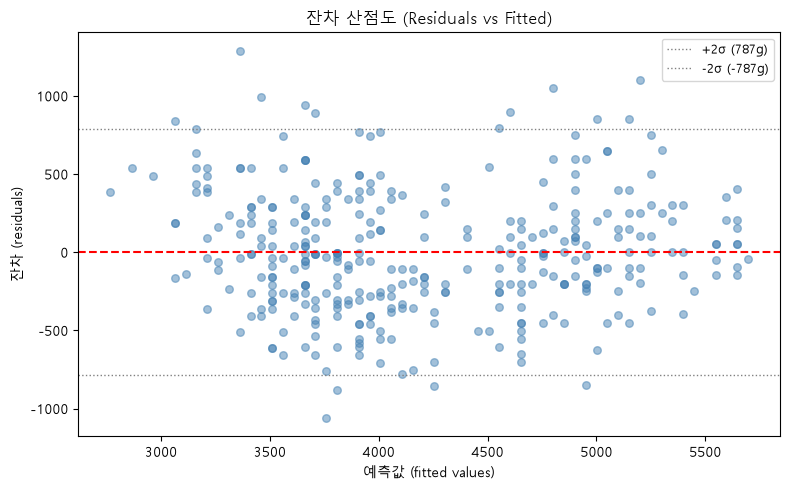

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(fitted, residuals, alpha=0.5, color='steelblue', s=30)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

ax.set_xlabel('예측값 (fitted values)')
ax.set_ylabel('잔차 (residuals)')
ax.set_title('잔차 산점도 (Residuals vs Fitted)')

# 잔차 ±2 표준편차 기준선 (참고용)
std_resid = residuals.std()
ax.axhline(2 * std_resid, color='gray', linestyle=':', linewidth=1, label=f'+2σ ({2*std_resid:.0f}g)')
ax.axhline(-2 * std_resid, color='gray', linestyle=':', linewidth=1, label=f'-2σ ({-2*std_resid:.0f}g)')

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
from statsmodels.stats.diagnostic import het_breuschpagan

lm_stat, lm_p, f_stat, f_p = het_breuschpagan(residuals, model_sm.model.exog)

print("=== 브루쉬-페이건 등분산성 검정 ===")
print(f"H₀ : 잔차의 분산이 일정하다 (등분산)")
print(f"H₁ : 잔차의 분산이 일정하지 않다 (이분산)")
print()
print(f"LM 통계량 : {lm_stat:.4f}")
print(f"LM p-값   : {lm_p:.4f}")
print(f"F  통계량 : {f_stat:.4f}")
print(f"F  p-값   : {f_p:.4f}")
print()

if lm_p < 0.05:
    print(f"p-값({lm_p:.4f}) < 0.05")
    print("→ 귀무가설을 기각한다. 이분산을 의심할 수 있다.")
    print("→ p-값과 신뢰구간을 그대로 신뢰하기 어려울 수 있다.")
else:
    print(f"p-값({lm_p:.4f}) ≥ 0.05")
    print("→ 귀무가설을 기각하지 못한다. 등분산 가정을 만족한다.")

=== 브루쉬-페이건 등분산성 검정 ===
H₀ : 잔차의 분산이 일정하다 (등분산)
H₁ : 잔차의 분산이 일정하지 않다 (이분산)

LM 통계량 : 2.1579
LM p-값   : 0.1418
F  통계량 : 2.1589
F  p-값   : 0.1427

p-값(0.1418) ≥ 0.05
→ 귀무가설을 기각하지 못한다. 등분산 가정을 만족한다.


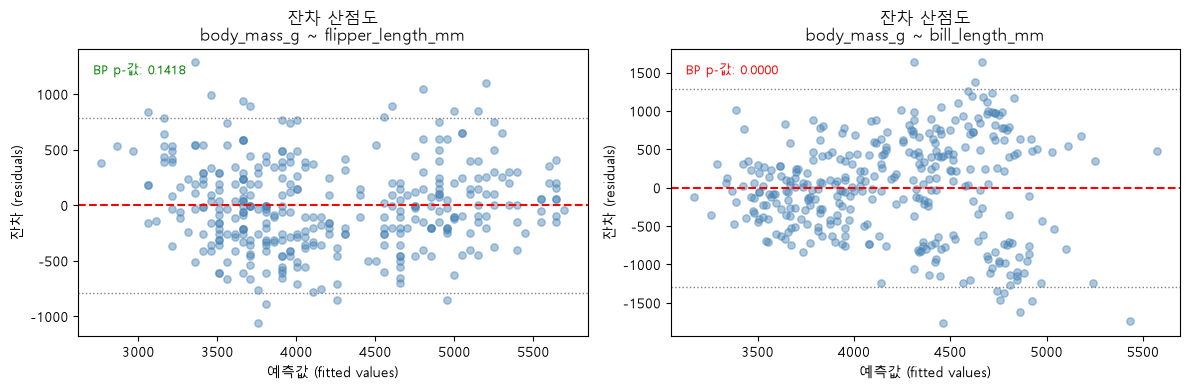

=== 두 모델 브루쉬-페이건 비교 ===
모델                            R²      BP p-값        등분산 판정
------------------------------------------------------------
flipper_length_mm         0.7590      0.1418            만족
bill_length_mm            0.3542      0.0000         위반 의심


In [28]:
# 비교군 모델 적합
X_bill = sm.add_constant(penguins_cleaned['bill_length_mm'].dropna())
y_bill = penguins_cleaned.loc[X_bill.index, 'body_mass_g']
model_bill = sm.OLS(y_bill, X_bill).fit()

fitted_bill   = model_bill.fittedvalues
residuals_bill = model_bill.resid

# 브루쉬-페이건
_, lm_p_flip, _, _ = het_breuschpagan(residuals,      model_sm.model.exog)
_, lm_p_bill, _, _ = het_breuschpagan(residuals_bill, model_bill.model.exog)

# 나란히 산점도
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, fv, rv, title, bp_p in [
    (axes[0], fitted,      residuals,      'flipper_length_mm', lm_p_flip),
    (axes[1], fitted_bill, residuals_bill, 'bill_length_mm',    lm_p_bill),
]:
    std_r = rv.std()
    ax.scatter(fv, rv, alpha=0.45, color='steelblue', s=28)
    ax.axhline(0,          color='red',  linestyle='--', linewidth=1.5)
    ax.axhline( 2*std_r,   color='gray', linestyle=':',  linewidth=1)
    ax.axhline(-2*std_r,   color='gray', linestyle=':',  linewidth=1)
    ax.set_xlabel('예측값 (fitted values)')
    ax.set_ylabel('잔차 (residuals)')
    ax.set_title(f'잔차 산점도\nbody_mass_g ~ {title}')
    ax.text(0.03, 0.95, f'BP p-값: {bp_p:.4f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            color='red' if bp_p < 0.05 else 'green')

plt.tight_layout()
plt.show()

# 수치 비교
print("=== 두 모델 브루쉬-페이건 비교 ===")
print(f"{'모델':<25} {'R²':>6}  {'BP p-값':>10}  {'등분산 판정':>12}")
print("-" * 60)
for name, mod, bp_p in [
    ('flipper_length_mm', model_sm,   lm_p_flip),
    ('bill_length_mm',    model_bill, lm_p_bill),
]:
    verdict = '만족' if bp_p >= 0.05 else '위반 의심'
    print(f"{name:<25} {mod.rsquared:>6.4f}  {bp_p:>10.4f}  {verdict:>12}")

▸
Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나요? 이 결과를 근거로 문제 3·4의 해석을 신뢰할 수 있을까요?
  - 잔차 산점도에서 점들이 예측값 전 범위에 걸쳐 0 주위에 고르게 퍼져 있었고, 브루쉬-페이건 p-값이 0.05보다 커서 등분산 가정을 기각하지 못했어요. 
  즉 OLS의 핵심 전제가 충족됐으므로 문제 3·4에서 구한 기울기, p-값, 신뢰구간을 신뢰할 수 있어요.

▸
Q5의 두 잔차 산점도는 어떻게 달랐나요? 비교군에서 관찰된 모양을 강의에서 배운 용어로 무엇이라 부르나요?
  - flipper 모델은 잔차가 예측값과 무관하게 고른 띠 모양이었어요. bill_length 모델은 예측값이 커질수록 잔차의 퍼짐도 함께 커지는 깔때기(부채꼴) 모양이었어요. 
  강의 용어로 이분산성(Heteroscedasticity) 이에요. 반대로 flipper 모델처럼 퍼짐이 일정한 상태를 등분산성(Homoscedasticity) 이라고 해요.

▸
비교군처럼 등분산성이 깨졌을 때, 잘못된 것은 기울기 값 자체인가요, 아니면 그 값의 통계적 해석인가요?
  - 기울기 값 자체는 아니에요. OLS는 등분산 가정이 깨져도 기울기의 불편추정량 성질은 유지돼요. 즉 49.69라는 숫자 자체는 여전히 최선의 추정값이에요. 
  잘못되는 건 그 값의 통계적 해석이에요. 표준오차가 잘못 계산되고, 그 결과 t통계량, p-값, 신뢰구간이 모두 왜곡돼요. "기울기가 유의하다"는 결론 자체를 믿기 어려워지는 거예요. 
  이럴 땐 이분산에 강건한 표준오차(Robust Standard Error)를 쓰는 방법이 있어요.

▸
R²가 1이 아니라는 것은 설명되지 않은 변동이 남아 있다는 뜻입니다. penguins 안에서 몸무게에 영향을 줄 만한데 우리 모델이 놓치고 있는 변수는 무엇일까요?
  - R² = 0.759라는 건 몸무게 변동의 24.1%는 날개 길이로 설명이 안 된다는 뜻이에요. penguins 안에서 충분히 영향을 줄 만한 변수들을 보면
  종, 성별, 부리 길이, 부리 깊이, 서식지 등이 있다

▸
그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요할까요?
  - 이 변수들을 동시에 넣으려면 다중회귀(Multiple Linear Regression) 가 필요해요. 
  단순회귀가 x 하나로 y를 설명하는 직선이라면, 다중회귀는 여러 x로 y를 설명하는 다차원 평면이에요.

In [29]:
# σ (표준오차) = 잔차의 표준편차
print(f"σ 추정값 (MSE의 제곱근) : {np.sqrt(model_sm.mse_resid):.2f}")
print(f"잔차 표준편차           : {residuals.std(ddof=2):.2f}")

# 실제로 쓰이는 곳
print(f"\n기울기의 표준오차 : {model_sm.bse['flipper_length_mm']:.4f}")
print(f"t통계량           : {model_sm.tvalues['flipper_length_mm']:.4f}")
print(f"= 기울기 / 표준오차: {model_sm.params['flipper_length_mm'] / model_sm.bse['flipper_length_mm']:.4f}")

σ 추정값 (MSE의 제곱근) : 394.28
잔차 표준편차           : 394.28

기울기의 표준오차 : 1.5184
t통계량           : 32.7222
= 기울기 / 표준오차: 32.7222
